In [2]:
import pandas as pd 

import matplotlib.pyplot as plt #MATPLOTLIB FOR VISUALISATION
from mplsoccer import Pitch #PITCH GRAPHIC


import seaborn as sns #USED FOR HEATMAP

In [31]:
#READ IN THE DATA

df = pd.read_csv('messibetis.csv')
df.head()

,player,minute,second,x,y,type,outcome,endX,endY
0,messi,45,0,50,50,Pass,Successful,40,43
1,messi,45,25,63,48,Pass,Successful,75,83
2,messi,46,4,74,58,Pass,Successful,71,65
3,messi,46,7,76,68,Pass,Successful,95,78
4,messi,46,55,100,1,Pass,Unsuccessful,96,38


In [32]:
#CONVERT DATA VALUES TO MATCH PITCH SCALE

df['x']= df['x']*1.2
df['y']= df['y']*.8

df['endX']= df['endX']*1.2
df['endY']= df['endY']*.8
df.head()

,player,minute,second,x,y,type,outcome,endX,endY
0,messi,45,0,60.0,40.0,Pass,Successful,48.0,34.4
1,messi,45,25,75.6,38.4,Pass,Successful,90.0,66.4
2,messi,46,4,88.8,46.4,Pass,Successful,85.2,52.0
3,messi,46,7,91.2,54.4,Pass,Successful,114.0,62.4
4,messi,46,55,120.0,0.8,Pass,Unsuccessful,115.2,30.4


Text(0.5, 1.0, 'Messi Passmap vs Real Betis')

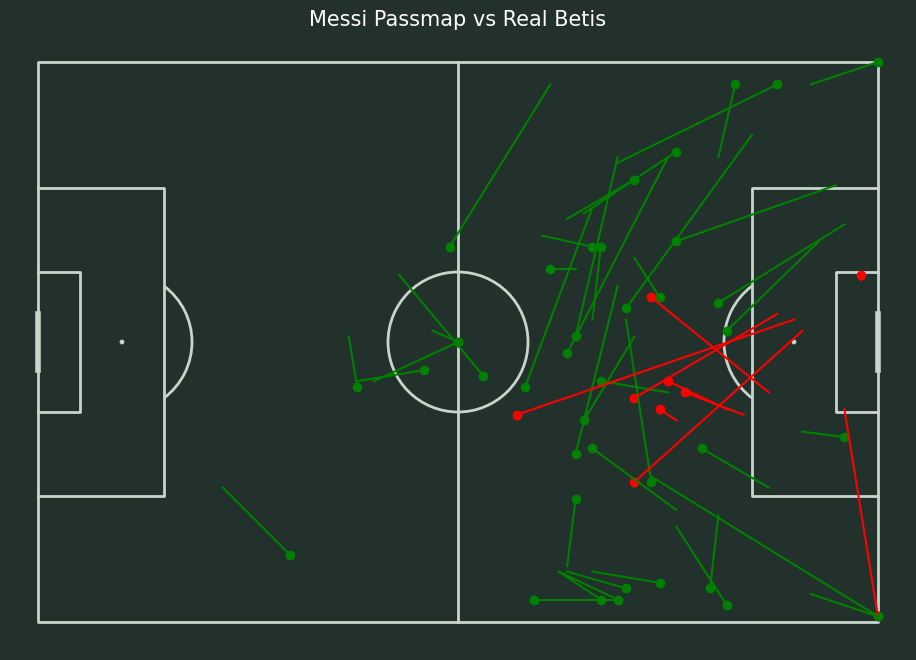

In [34]:
#CREATE FIGURE 

fig,ax = plt.subplots(figsize=(13.5,8)) #CREATES FIGURE AXIS
fig.set_facecolor('#22312b') #CHANGE OUTSIDE COLOUR TO DARK GREEN
ax.patch.set_facecolor('#22312b') #CHANGE INSIDE COLOUR TO DARK GREEN

pitch = Pitch(pitch_type='statsbomb', #ADD PITCH ON TOP OF FIGURE
              pitch_color='#22312b',
              line_color='#c7d5cc',
             )

pitch.draw(ax=ax)

plt.gca().invert_yaxis() #THE STATSBOMB Y-AXIS BEGINS IN THE TOP LEFT CORNER SO WE NEED TO SWAP IT TO THE BOTTOM LEFT TO MATCH THE X-AXIS

for x in range(len(df['x'])): #SETS LOOP TO ITERATE OVER THE LENGTH OF COLUMN X (THE FULL DATAFRAME OF VALUES)
    if df['outcome'][x] == 'Successful':
        plt.plot((df['x'][x],df['endX'][x]),(df['y'][x],df['endY'][x]), color='green') #PASS THROUGH THE SUCCESSFUL PASS COORDINATES WITH X, ENDX, Y, ENDY VALUES
        plt.scatter(df['x'][x],df['y'][x], color='green')
    if df['outcome'][x] == 'Unsuccessful':
        plt.plot((df['x'][x],df['endX'][x]),(df['y'][x],df['endY'][x]), color='red') #PASS THROUGH THE UNSUCCESSFUL PASS COORDINATES WITH X, ENDX, Y, ENDY VALUES
        plt.scatter(df['x'][x],df['y'][x], color='red')

plt.title('Messi Passmap vs Real Betis', color='white',size=15)